![Logos](img/logos.png)

# 3.6 Comparison of VIIRS and MONARCH dust AOD

#### Objective

The objective of this notebook is to compare and analyse the dust event across its entire duration with VIIRS observations and MONARCH forecasts by employing MAPIES.

## Comparison set-up

As we have seen previously, the peak of the event occurs around 2025-03-05 just over Cyprus, both in VIIRS and in MONARCH. While having individual dust AOD plots is useful, a more direct comparison is more appropriate to truly understand how the modelled dust values and distribution compare against the observed event.

## Using MAPIES to compare dust forecasts

MAPIES has an in-built feature that allows us to directly compare input data from a model to MAPIES outputs, which is the `model_data_comparison()` method. We will use this method to compare our MONARCH dust models against VIIRS observations.

It uses the following parameters:

~~~
model_data_comparison(model=model, model_dir=model_dir, model_variable=model_variable, frequency_avg="D", apply_qa=True, min_num_obs=0, geospatial_crop=None,method="efficient", forecast=["day1"], plot_model=True, plot_difference=True, save=True, outdir=outdir)
~~~



<table>
<tr>
<th>Parameter</th>
<th>Description</th>
<th>Example</th>
</tr>
<tr>
<td>

`model`
</td>
<td>Specifies the name of the MODEL:</td>
<td>

`model = MONARCH`
</td>
</tr>
<tr>
<td>

`model_dir`
</td>
<td>Specifies the directory of the model data.</td>
<td></td>
</tr>
<tr>
<td>

`model_variable`
</td>
<td>Used to indicate which model variable we are interested in.</td>
<td>

`model_variable = "od550du"`
</td>
</tr>
<tr>
<td>

`frequency_avg`
</td>
<td>

Frequency at which MAPIES data has to be averaged. It follows the same specifications as `frequency_avg` of `process_avg_data()`.
</td>
<td>

`frequency_avg = "D"`
</td>
</tr>
<tr>
<td>

`apply_qa`
</td>
<td>

Applies the quality assurance flags set in the `satellite_config.yaml` file. It is the same as in `process_avg_data()`.
</td>
<td></td>
</tr>
<tr>
<td>

`min_num_obs`
</td>
<td>

Sets the minimum number of observations in a grid cell to proceed with the analysis. Requires an integer number as input. It is the same as in `process_avg_data()`.
</td>
<td>

`min_num_obs = 10`
</td>
</tr>
<tr>
<td>

`geospatial_crop`
</td>
<td>

Utilises two sets of coordinates to form a geospatial frame that limits data processing to inside this region. It is the same as in `process_avg_data()`.
</td>
<td>

`geospatial_crop=[[43.8, -9.3], [36, 3.3]]`
</td>
</tr>
<tr>
<td>

`method`
</td>
<td>

To decide which type of model comparison we want to perform:

* `efficient` : compares MAPIES-averaged data with model data averaged to the same frequency, using time-based matching (no spatial interpolation).
* `precise` : compares satellite (VIIRS) data directly with the model, using spatial interpolation (LinearNDInterpolator) to map the model grid to the satellite observation points.
</td>
<td></td>
</tr>
<tr>
<td>

`forecast`
</td>
<td>Specifies which day of forecast data inside each model file we want to use for the model comparison.</td>
<td>

`forecast=["day1"]`
</td>
</tr>
<tr>
<td>

`plot_model`
</td>
<td>

Determines whether the model data is plotted through MAPIES plotting functions. It can be set to:

* `True` (default)
* `False`
</td>
<td></td>
</tr>
<tr>
<td>

`plot_obs`
</td>
<td>

Determines whether the MAPIES data (satellite observations) is plotted through MAPIES plotting functions. It can be set to:

* `True` (default)
* `False`
</td>
<td></td>
</tr>
<tr>
<td>

`plot_difference`
</td>
<td>

Determines whether the results from the comparison are plotted through MAPIES plotting functions. It can be set to:

* `True` (default)
* `False`
</td>
<td></td>
</tr>
<tr>
<td>

`save`
</td>
<td>

Determines whether the difference data is saved to a .nc file. The data is saved in flattened arrays. It can be:

* `True` (default)
* `False`
</td>
<td></td>
</tr>
<tr>
<td>

`outdir`
</td>
<td>It specifies the output directory where to save the netCDF files or the images.</td>
<td></td>
</tr>
<tr>
<td>

`display_fig`
</td>
<td>

Displays the output plot in a Jupyter Notebook. It has two possible inputs:

* True
* False (default)
</td>
<td></td>
</tr>
</table>

We can make use of this functionality by directly calling the VIIRS object and without the need to pre-process our observational data.

In [1]:
import sys
sys.path.append("/home/jupyter-tvintimi/atarri/tools/mapies")

In [2]:
%matplotlib inline
from mapies.viirs import VIIRS
import numpy as np
import time

In [3]:
## Configurations
start_date = "202503040000"
end_date = "202503060000"
model = "MONARCH" #name of your model
outdir = "../plot_outputs" #path where your plots and MAPIES output files are stored
indir = '/shared/data/VIIRS/original_files/2025' 
model_dir = "/shared/data/exp_to_interp/monarch/regional/3hourly/od550_dust" # path where your model data is located
model_variable = "od550_dust" ## add model variable

## Grid settings

Before we call the VIIRS object, we need to make sure that our grid parameters are set correctly. Earlier, we looked at the available grids available in MAPIES to output our processed satellite data. We can, however, specifically look at these settings in the `/mapies/config/satellite_config.yaml` file. This file allows us to flexibly set and edit our grid configurations, according to what our needs are. Previously, we used the `regular` grid to process our observational datasets:

~~~
regular:
        west: -180
        south: -90
        dlon: 0.2
        dlat: 0.2
        #nlon: 3600
        #nlat: 1800
~~~

This grid configuration assumes that our input model file dimensions will be centered around 0, at a resolution of 0.2 x 0.2 and with a westernmost point of -180 and southernmost point of -90. However, as we have seen from our MONARCH files, our models do not have this configuration. Rather, our files have a resolution of 0.1 x 0.1 and are not centered around 0; our latitude range is -10.95 to 71.45 and our longitude range is -62.95 to 101.95. If we were to run the model comparison with the regular grid configuration, MAPIES would erroneously match or interpolate model data from outside its current bounds and output an incorrect comparison. Because of this, and since we do not have a grid that exactly matches our current models, we will customise our grid with the following settings:

~~~
regular:
        west: -62.95
        south: -10.95
        dlon: 0.1
        dlat: 0.1
        nlon: 1650
        nlat: 825
~~~

where:

- west: westernmost longitude point
- south: southernmost longitude point
- dlon: resolution of the longitude of our grid.
- dlat: resolution of the latitude of our grid.
- nlat: size of the latitude dimension.
- nlon: size of the longitude dimension.

We will add this to the .yaml file and call the VIIRS object.

In [4]:
 ## call VIIRS object
c = VIIRS(start_date, end_date, outdir=outdir, indir=indir, grid_repr="regular")
c.gather_nc_files()

Enter resolution or number of grid cells


Now, we will call the model comparison function. We will look at our first day of forecast, select the daily average option and plot both the model average as well as the comparison itself. Finally, we will select the `efficient` method to perform a time-based matching of both data.

2026-07-28 10:15:00.142 | INFO     | mapies.util.settings:setup_filters:125 - QA: True
2026-07-28 10:15:00.144 | INFO     | mapies.util.settings:setup_filters:126 - Applying QA flags: {'qa_land': {'qa_name': 'Aerosol_Optical_Thickness_QA_Flag_Land', 'qa_values': [2, 3], 'qa_combined': False}, 'qa_ocean': {'qa_name': 'Aerosol_Optical_Thickness_QA_Flag_Ocean', 'qa_values': [3], 'qa_combined': False}, 'qa_type': {'qa_name': 'Aerosol_Type_Land_Ocean', 'qa_values': [0], 'qa_combined': True}}
2026-07-28 10:15:00.144 | INFO     | mapies.interpolation.viirs_interpolation:get_model_data:45 - Reading in model data /shared/data/exp_to_interp/monarch/regional/3hourly/od550_dust/od550_dust_2025030400.nc
2026-07-28 10:15:14.061 | INFO     | mapies.interpolation.viirs_interpolation:get_model_data:69 - Model frequency: 3 hours
/home/jupyter-tvintimi/atarri/tools/mapies/mapies/viirs.py:143: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_ranges["

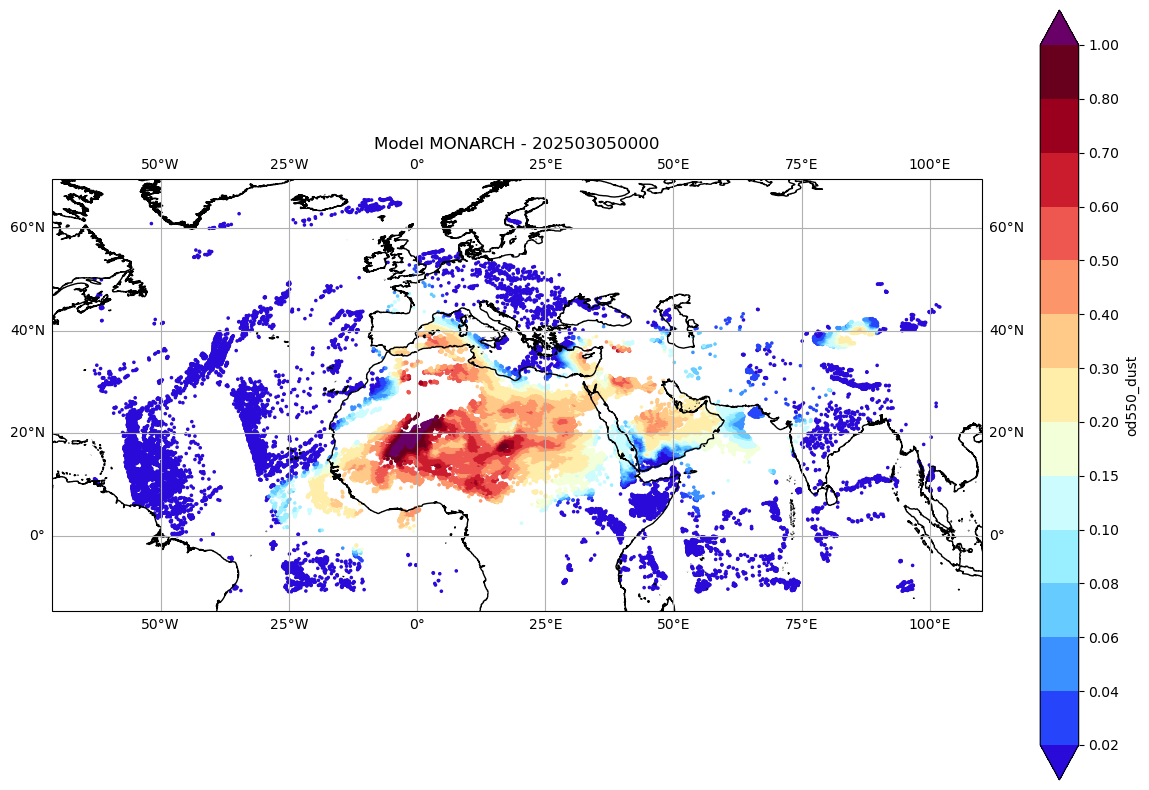

2026-07-28 10:16:17.436 | INFO     | mapies.util.plotting:plot_2D_obs_custom:98 - Saved plot: ../plot_outputs/MONARCH_model_file_od550_dust_2025030400_202503050000.png


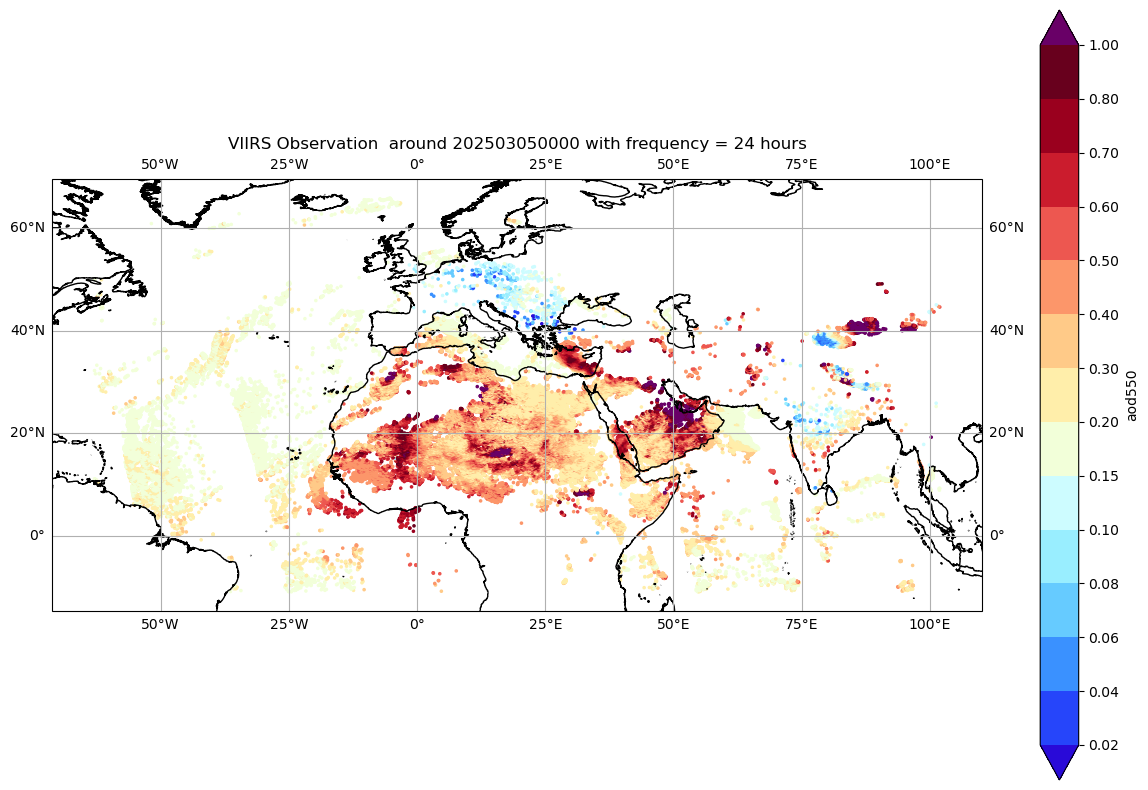

2026-07-28 10:16:34.517 | INFO     | mapies.util.plotting:plot_2D_obs_custom:98 - Saved plot: ../plot_outputs/viirs_2D_obs_around_202503050000.png


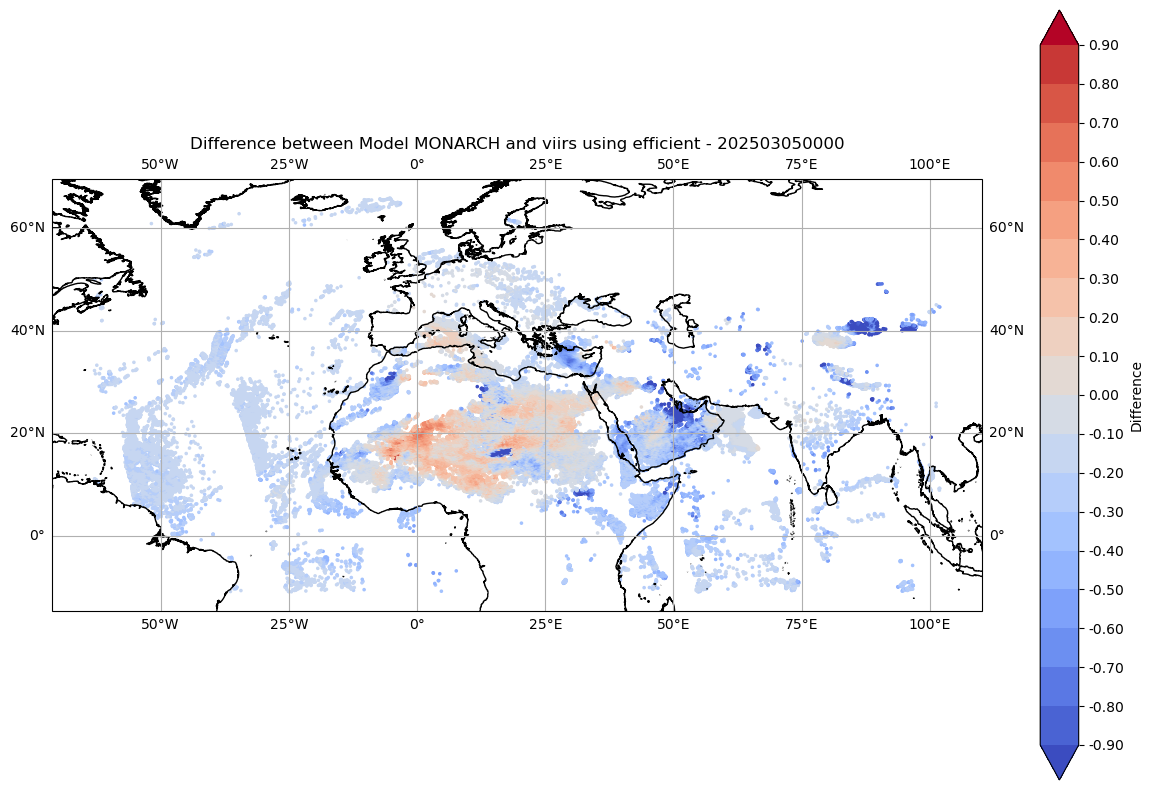

2026-07-28 10:16:51.866 | INFO     | mapies.util.plotting:plot_2D_difference:227 - Saved plot: ../plot_outputs/Difference_MONARCH_model_file_od550_dust_2025030400_vs_viirs_using_efficient_202503050000.png
2026-07-28 10:16:54.024 | INFO     | mapies.util.saving:to_netCDF:123 - Saved data to netCDF file: ../plot_outputs/Difference_viirs_data_vs_MONARCH_model_file_od550_dust_2025030400_202503050000.nc
2026-07-28 10:16:54.149 | INFO     | mapies.interpolation.viirs_interpolation:get_model_data:45 - Reading in model data /shared/data/exp_to_interp/monarch/regional/3hourly/od550_dust/od550_dust_2025030500.nc
2026-07-28 10:16:54.735 | INFO     | mapies.interpolation.viirs_interpolation:get_model_data:69 - Model frequency: 3 hours
/home/jupyter-tvintimi/atarri/tools/mapies/mapies/viirs.py:143: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_ranges["day1"] = pd.date_range(day1_start, day2_start, freq=frequency, inclusive="left")
/home/jup

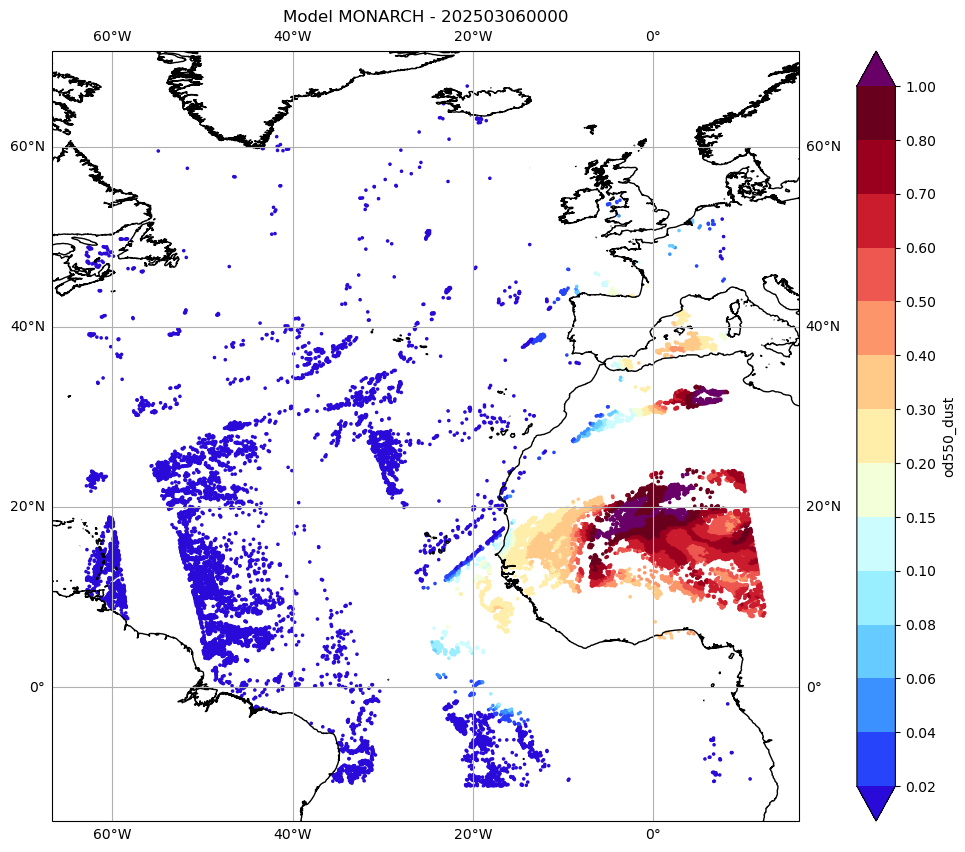

2026-07-28 10:17:48.017 | INFO     | mapies.util.plotting:plot_2D_obs_custom:98 - Saved plot: ../plot_outputs/MONARCH_model_file_od550_dust_2025030500_202503060000.png


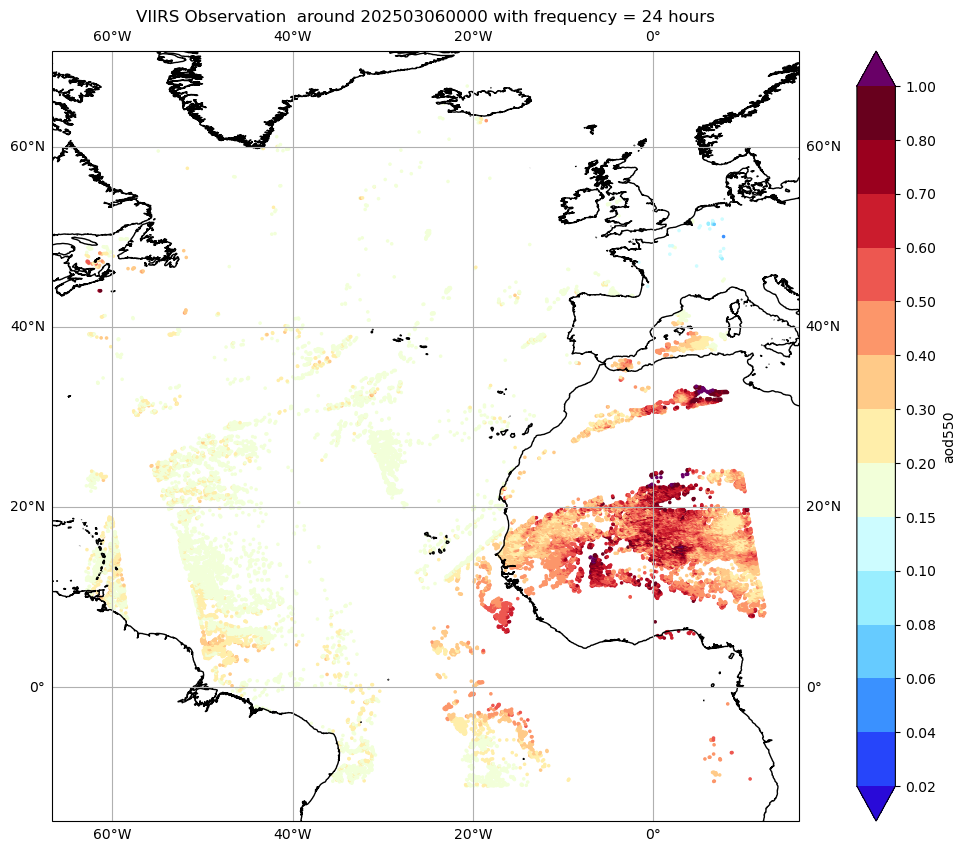

2026-07-28 10:18:03.909 | INFO     | mapies.util.plotting:plot_2D_obs_custom:98 - Saved plot: ../plot_outputs/viirs_2D_obs_around_202503060000.png


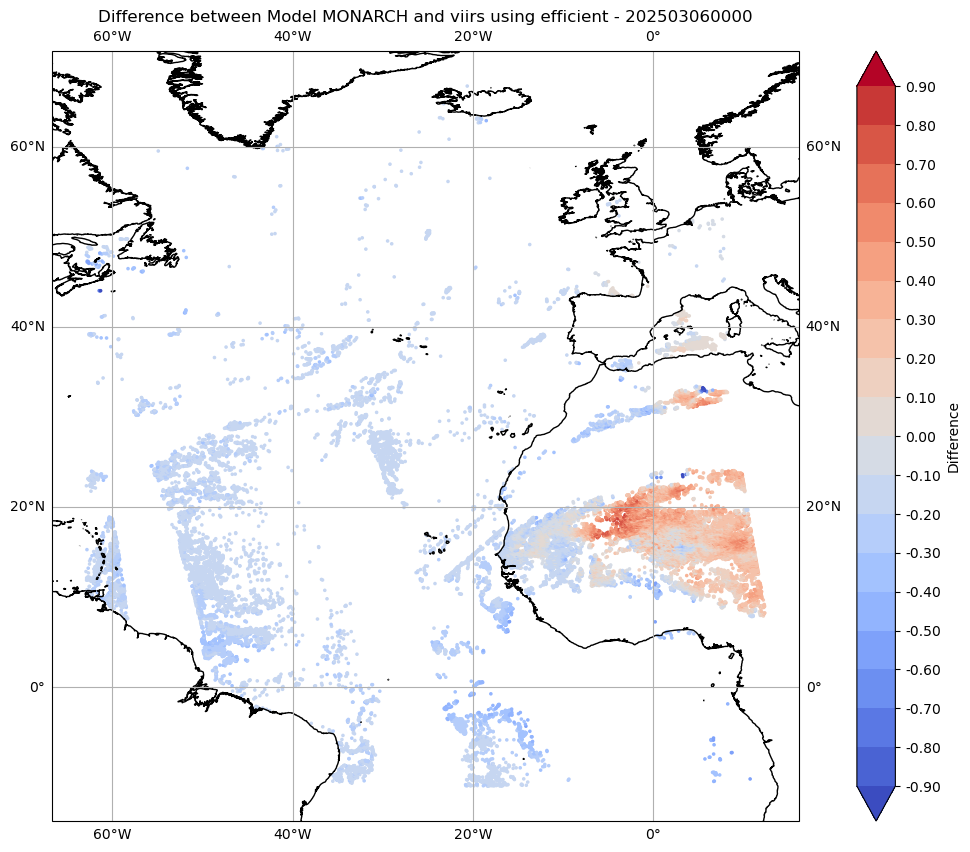

2026-07-28 10:18:19.904 | INFO     | mapies.util.plotting:plot_2D_difference:227 - Saved plot: ../plot_outputs/Difference_MONARCH_model_file_od550_dust_2025030500_vs_viirs_using_efficient_202503060000.png
2026-07-28 10:18:19.960 | INFO     | mapies.util.saving:to_netCDF:123 - Saved data to netCDF file: ../plot_outputs/Difference_viirs_data_vs_MONARCH_model_file_od550_dust_2025030500_202503060000.nc
2026-07-28 10:18:20.100 | INFO     | mapies.interpolation.viirs_interpolation:get_model_data:45 - Reading in model data /shared/data/exp_to_interp/monarch/regional/3hourly/od550_dust/od550_dust_2025030600.nc
2026-07-28 10:18:20.791 | INFO     | mapies.interpolation.viirs_interpolation:get_model_data:69 - Model frequency: 3 hours


In [ ]:
c.model_data_comparison(model = model,
                        frequency_avg='D', ## add daily frequency
                        model_dir=model_dir,
                        model_variable=model_variable,
                        method="efficient",
                        forecast=["day1"],
                        plot_model=True,
                        plot_difference=True,
                        save=True,
                        display_fig=True,
                        outdir=outdir)

Check your output folder and analyse the comparison plots. What do you see? Discuss with your colleagues.

## References and further reading

MAPIES is an Python framework developed at BSC-CNS. For more information, please contact [Calum Meikle](mailto:calum.meikle@bsc.es) and [Carlotta Gilè](mailto:carlotta.gile@bsc.es).

[1] VIIRS information: https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/viirs/

[2] We thank the Deep Blue science team (https://deepblue.gsfc.nasa.gov) for the VIIRS Deep Blue aerosol data record.

VIIRS data downloaded from [EARTHDATA](https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/5200/AERDB_L2_VIIRS_NOAA20/)

<table style="width:100%;">
    <tr>
        <td style="text-align: center;"><a href="VT3-4-VIIRS_MAPIES.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT3-6-Workshop.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr>
</table>